
Installation and setup of the MRL framework and dependencies


The MRL (Molecular Representation Learning) framework is an open-source library
developed by Dark Matter AI for de novo peptide design using deep learning.
Source: https://github.com/DarkMatterAI/mrl

The following lines install the library in development mode (-e),
allowing us to modify the source code and have changes take effect immediately.
The clone command is commented out because the repository is already present
in the working environment; this avoids re-downloading on each run.

The path insertion ensures the modified MRL library is loaded before any system-wide installation.
This is specific to the Paperspace environment; adjust the path if running elsewhere.

In [1]:
# ============================================================
# 1. INSTALLATION AND SETUP
# ============================================================
# This notebook requires a modified version of the MRL framework.
# The 'mrl' directory must be present in the working directory.
# 
# To obtain it:
# 1. Clone the official MRL repository: 
#    git clone https://github.com/DarkMatterAI/mrl.git
# 2. Copy the custom modifications provided in this repository
#    (see the 'custom/' folder and the README for details)
#
# IMPORTANT: The official MRL repository is NOT compatible with this notebook
# without the modifications. Please follow the setup instructions in the README.
# ============================================================

# Install MRL in development mode (assumes mrl/ is present)
!cd mrl && pip install -e .

# Dependency
!pip install rdkit-pypi fair-esm biopython pandas scikit-learn matplotlib seaborn selfies>=2.0.0 fastprogress==1.0.3

# Check
!python -c "from mrl.imports import *; print('MRL OK!')"

Obtaining file:///notebooks/MRL-AMP-generation/notebooks/mrl
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 127.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.4/29.4 MB 70.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.9/151.9 kB 28.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 MB 47.8 MB/s eta 0:00:00:00:010:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.7/83.7 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.0/76.0 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.4/95.4 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.1/83.1 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.5/68.5 kB 11.0 MB/s eta 0:00:00
   ━━━━

In [2]:
# Restart the kernel BEFORE this cell
import sys
import os

# Add the MRL library to the Python path
# The 'mrl' directory should be in the same folder as this notebook,
# or in the parent folder (depending on your setup).
mrl_path = os.path.join(os.getcwd(), 'mrl')
if os.path.exists(mrl_path):
    sys.path.insert(0, mrl_path)
else:
    # Fallback for Paperspace environment (if running there)
    sys.path.insert(0, '/storage/mrl')

from mrl.imports import *
from mrl.core import *
print("✅ Imports MRL OK !")

✅ Imports MRL OK !


In [3]:
import pandas as pd
import warnings

# Patch to handle deprecated DataFrame.append method
# The official solution is to use pd.concat() instead, but this patch
# ensures backward compatibility with existing code that uses .append()
def _safe_append(self, other, ignore_index=False, **kwargs):
    if isinstance(other, (dict, pd.Series)):
        other = pd.DataFrame([other])
    return pd.concat([self, other], ignore_index=ignore_index, **kwargs)

# Apply patch to pandas DataFrame
pd.DataFrame.append = _safe_append

# Suppress FutureWarning messages related to deprecated methods
warnings.filterwarnings('ignore', category=FutureWarning)

# Note: This patch is a temporary workaround. For new code, prefer pd.concat()

# Antimicrobial Peptide Design

>Using MRL to design antimicrobial peptides

## Antimicrobial Peptide Design

This tutorial runs an end to end workflow for designing antimicrobial peptides using MRL.

Antimicrobial peptides are a family of peptides that kill bacteria. These peptides are of interest for antibiotics and anticancer therapeutics

## Performance Notes

The workflow in this notebook is more CPU-constrained than GPU-constrained due to the need to evaluate samples on CPU. If you have a multi-core machine, it is recommended that you uncomment and run the `set_global_pool` cells in the notebook. This will trigger the use of multiprocessing, which will result in 2-4x speedups.

This notebook may run slow on Collab due to CPU limitations.

If running on Collab, remember to change the runtime to GPU

In [4]:
# ============================================================
# 3. IMPORTS (MRL and additional libraries)
# ============================================================
# This cell imports all necessary modules from MRL and other libraries.
# The MRL path should already be set in Cell 2.
# ============================================================

# MRL core modules
from mrl.imports import *
from mrl.core import *
from mrl.chem import *
from mrl.templates.all import *

# MRL PyTorch modules
from mrl.torch_imports import *
from mrl.torch_core import *
from mrl.layers import *
from mrl.dataloaders import *
from mrl.g_models.all import *
from mrl.vocab import *
from mrl.policy_gradient import *
from mrl.train.all import *
from mrl.model_zoo import *

# Additional libraries
from sklearn.metrics import roc_curve, auc, roc_auc_score

In [5]:
os.makedirs('untracked_files', exist_ok=True)

## Data

The dataset comes from the [AMPlify](https://github.com/bcgsc/AMPlify) repo. It contains ~8300 short peptides classified as antimicrobial or not antimicrobial

In [72]:
df = pd.read_csv('../data/anti_microbial_peptides.csv')

In [73]:
df = df[["name",'sequence', "dataset", "label"]]
df.head()
#print(df["label"].value_counts())

,name,sequence,dataset,label
0,>trAMP0001,GLLDTFKNLALNAAKSAGVSVLNSLSCKLSKTC,train,1
1,>trAMP0002,AKKPVAKKAAGGVKKPK,train,1
2,>trAMP0003,GIIDIAKKLVGGIRNVLGI,train,1
3,>trAMP0004,MAGFLKVVQLLAKYGSKAVQWAWANKGKILDWLNAGQAIDWVVSKI...,train,1
4,>trAMP0005,YGPGDGHGGGHGGGHGGGHGNGQGGGHGHGPGGGFGGGHGGGHGGG...,train,1


Most peptides are short, less than 50 amino acids

<Axes: >

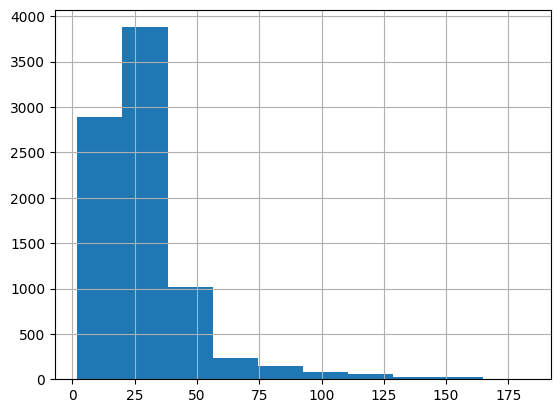

In [66]:
df.sequence.map(lambda x: len(x)).hist()

## Score Function

Now we want to develop a score function for predicting antimicrobial activity. We will use a CNN encoder with a MLP head to predict a binary classification value for antimicrobial activity.

Our input data will be token integers for amino acids. Note that fingerprint representations are a poor fit for peptide work because peptides contain many repeating substructures.

We will train on 95% of the data and validate on the 5% held out.

In [67]:
train_df = df[df.dataset=='train']
valid_df = df[df.dataset=='valid']

In [68]:
aa_vocab = CharacterVocab(AMINO_ACID_VOCAB)

amp_ds = Text_Prediction_Dataset(train_df.sequence.values, train_df.label.values, aa_vocab)
test_ds = Text_Prediction_Dataset(valid_df.sequence.values, valid_df.label.values, aa_vocab)

This is the model we will use:

In [11]:
class Predictive_CNN(nn.Module):
    def __init__(self,
                 d_vocab,
                 d_embedding,
                 d_latent,
                 filters,
                 kernel_sizes,
                 strides,
                 dropouts,
                 mlp_dims,
                 mlp_drops,
                 d_out
                ):
        super().__init__()

        self.conv_encoder = Conv_Encoder(
                                        d_vocab,
                                        d_embedding,
                                        d_latent,
                                        filters,
                                        kernel_sizes,
                                        strides,
                                        dropouts,
                                    )

        self.mlp_head = MLP(
                            d_latent,
                            mlp_dims,
                            d_out,
                            mlp_drops
                            )

    def forward(self, x):
        encoded = self.conv_encoder(x)
        out = self.mlp_head(encoded)
        return out

In [12]:
d_vocab = len(aa_vocab.itos)
d_embedding = 256
d_latent = 512
filters = [256, 512, 1024]
kernel_sizes = [7, 7, 7]
strides = [2,2,2]
dropouts = [0.2, 0.2, 0.2]
mlp_dims = [512, 256, 128]
mlp_drops = [0.2, 0.2, 0.2]
d_out = 1


amp_model = Predictive_CNN(
                    d_vocab,
                    d_embedding,
                    d_latent,
                    filters,
                    kernel_sizes,
                    strides,
                    dropouts,
                    mlp_dims,
                    mlp_drops,
                    d_out
                )

In [13]:
r_agent = PredictiveAgent(amp_model, BinaryCrossEntropy(), amp_ds, opt_kwargs={'lr':1e-3})

In [14]:
r_agent.train_supervised(32, 12, 1e-3)

Epoch,Train Loss,Valid Loss,Time
0,0.45252,0.37152,00:09
1,0.36080,0.37825,00:02
2,0.33118,0.45458,00:02
3,0.30328,0.39829,00:02
4,0.27629,0.36765,00:02
5,0.23545,0.39597,00:02
6,0.23098,0.36216,00:01
7,0.19650,0.32896,00:01
8,0.15868,0.45021,00:02
9,0.11127,0.35161,00:02


Optional: save score function weights

In [15]:
r_agent.save_weights('untracked_files/amp_predictor.pt')

Optional: to load the exact weights used, run the following:

In [16]:
r_agent.load_state_dict(model_from_url('amp_predictor.pt'))

Downloading: "https://dmai-mrl.s3.amazonaws.com/mrl_public/amp_predictor.pt" to /root/.cache/torch/hub/checkpoints/amp_predictor.pt
100%|██████████| 23.0M/23.0M [00:01<00:00, 19.8MB/s]


In [17]:
# validate

valid_dl = test_ds.dataloader(256, shuffle=False)
r_agent.model.eval();

preds = []
targs = []

with torch.no_grad():
    for i, batch in enumerate(valid_dl):
        batch = to_device(batch)
        x,y = batch
        pred = r_agent.model(x)
        preds.append(pred.detach().cpu())
        targs.append(y.detach().cpu())

preds = torch.cat(preds).numpy()
targs = torch.cat(targs).numpy()

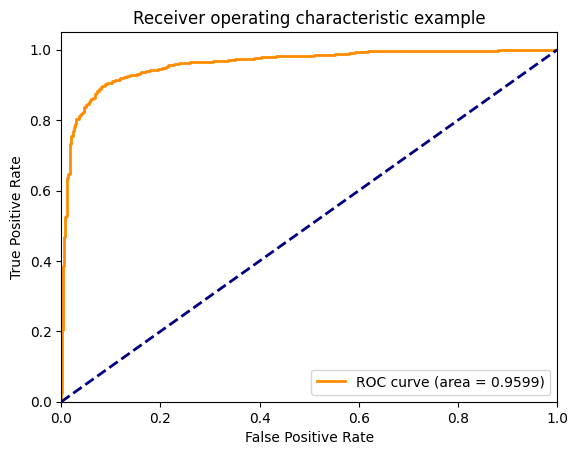

In [18]:
fpr, tpr, _ = roc_curve(targs, torch.tensor(preds).sigmoid().squeeze().numpy())
roc_auc = auc(fpr, tpr)

plt.figure()
lw = 2
plt.plot(fpr, tpr, color='darkorange',
         lw=lw, label='ROC curve (area = %0.4f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic example')
plt.legend(loc="lower right")
plt.show()

**Chemical space**

The chemical space defines the set of sequences that the generative model is allowed to explore. By applying carefully chosen filters, we restrict the generation to peptides with desirable physicochemical properties while excluding sequences that are likely to be inactive, unstable, or toxic.

**Defining the chemical space.**

The choice of constraints is critical: overly restrictive filters may prevent the discovery of novel active sequences, while overly permissive filters may generate sequences with poor drug-like properties. In practice, finding the right balance is an **iterative process**.

**Selection of constraints.**

The constraints used in this work were selected based on two criteria: (i) their established importance in AMP activity, and (ii) the properties of the peptide of choice (here Lynronne‑1), which served as a reference template.

- **Cationic charge.** The positive charge of AMPs is essential for electrostatic interaction with negatively charged bacterial membranes. The range can be adjusted based on the desired properties.

- **Hydrophobicity.** Hydrophobicity influences membrane insertion and amphipathicity. The range was chosen to preserve the balance between solubility and membrane affinity.

- **Hydrophobic moment.** This parameter measures amphipathicity, which is critical for membrane disruption. The range ensures that generated peptides maintain an amphipathic character.

- **Exclusion of some amino acids.** Certain amino acids can be excluded, for example, cysteine, to prevent disulfide bridge formation and aggregation; and aspartate and glutamate, because their negative charge at physiological pH would reduce the net positive charge, weakening electrostatic interactions with bacterial membranes.

- **Limitation of residue frequency (max 0.4 per length).** A maximum residue frequency of 40% was imposed to prevent the generation of homopolymeric sequences (e.g., "MSSSSSSSRP"), which are a common failure mode of generative models trained on simplistic score functions.

- **Length constraint (10–75 residues).** Sequences were limited to a maximum of 75 residues to maintain consistency with the training dataset and to avoid generating peptides that would be impractical to synthesize.

**Hard vs. soft filters.**

The constraints were implemented as two types of filters:

- **Hard filters:** sequences that do not meet these criteria are rejected outright. These included validity, length, residue frequency, and the exclusion of cysteine, aspartate, and glutamate.

- **Soft filters:** sequences that deviate from the desired ranges receive a lower score but are not rejected. These included cationic charge, hydrophobicity, and hydrophobic moment. This approach allowed the model to explore sequences near the boundaries of the desired property space, potentially discovering novel active sequences that fall slightly outside the predefined ranges.

This flexible filtering strategy enabled the generation of diverse sequences while maintaining a strong bias towards peptides with physicochemical properties favourable for antimicrobial activity.

Create two new class `Hydrophobicity and Hydrophobicity_Moment` to calculate these two values and create a filter to validate only sequences in a certain range.

In [19]:
import math
from rdkit import Chem

moon_fleming_scale = {
    "A": -1.57,
    "R": 2.14,
    "N": 1.91,
    "D": 1.38,
    "C": -1.08,
    "Q": 1.44,
    "E": 0.07,
    "G": 0.15,
    "H": 3.19,
    "I": -3.12,
    "L": -3.32,
    "K": 3.82,
    "M": -2.33,
    "F": -3.77,
    "P": -3.09,
    "S": 0.26,
    "T": 0.21,
    "W": -1.95,
    "Y": -2.66,
    "V": -2.34,
}

def get_hydrophobic_values(mol: str) -> list[float]:
    """
    Transform each aminoacid in the hydrophobic value in the scale

    :param mol: The sequence of the peptide
    :return hvalues: The sequence of the peptide using the scale
    """
    hvalues = []

    for aa in mol:
        sc_hydrophobicity = moon_fleming_scale.get(aa, None)
        if sc_hydrophobicity is None:
            raise KeyError("Amino acid not defined in scale: {}".format(aa))
        hvalues.append(sc_hydrophobicity)
    return hvalues


def calculate_moment(mol: str) -> float:
    """
    Calculates the hydrophobic dipole moment from an array of hydrophobicity
    values. Formula defined by Eisenberg, 1982 (Nature). Returns the average
    moment (normalized by sequence length)

    uH = sqrt(sum(Hi cos(i*d))**2 + sum(Hi sin(i*d))**2),
    where i is the amino acid index and d (delta) is an angular value in
    degrees (100 for alpha-helix, 180 for beta-sheet).

    :param mol: The sequence of the peptide
    :return hm: The value of hydrophobic moment
    """
    mol1 = Chem.MolToSequence(mol)
    angle = 100
    sum_cos, sum_sin = 0.0, 0.0
    hvalues = get_hydrophobic_values(mol1)
    for i, hv in enumerate(hvalues):
        rad_inc = ((i * angle) * math.pi) / 180.0
        sum_cos += hv * math.cos(rad_inc)
        sum_sin += hv * math.sin(rad_inc)
    return math.sqrt(sum_cos**2 + sum_sin**2) / len(hvalues)


def calculate_hydrophobicity(mol: str) -> float:
    """
    Calculates the hydrophobicity value to each amino acid in the sequence

    :param mol: The sequence of the peptide
    :return h: The hydrophobicity of the mol
    """
    mol1 = Chem.MolToSequence(mol)
    hvalues = get_hydrophobic_values(mol1)
    hydrophobicity = sum(hvalues) / len(hvalues)
    return hydrophobicity


class HydrophobicityFilter(PropertyFilter):
    def __init__(self, min_val, max_val, score=None, name=None, **kwargs):
        super().__init__(
            calculate_hydrophobicity,
            min_val=min_val,
            max_val=max_val,
            score=score,
            name=name,
            **kwargs,
        )


class HydrophobicityMomentFilter(PropertyFilter):
    def __init__(self, min_val, max_val, score=None, name=None, **kwargs):
        super().__init__(
            calculate_moment,
            min_val=min_val,
            max_val=max_val,
            score=score,
            name=name,
            **kwargs,
        )

Create A new class `CombinedCharacterCountFilter` to count combined character as one, like 'R' and 'K' count as 'charged amino acid'

In [20]:
class CombinedCharacterCountFilter(Filter):
    '''
    CombinedCharacterCountFilter - validates `Mol` based on the combined count of specified characters

    Inputs:
    - `char_groups list[list[str]]`: list of character groups to count as a single entity
    - `min_val Optional[float, int]`: min value for count
    - `max_val Optional[float, int]`: max value for count
    - `per_length bool`: if True, counts are normalized by string length
    - `score [None, int, float, ScoreFunction]`: see `Filter.set_score`
    - `name Optional[str]`: filter name used for repr
    - `fail_score [float, int]`: used in `Filter.set_score` if `score_function` is (int, float)
    - `mode str['smile', 'protein', 'dna', 'rna']`: determines how inputs are converted to Mol objects
    '''
    def __init__(self, char_groups, min_val=None, max_val=None, per_length=False,
                 score=None, name=None, fail_score=0., mode='smile'):
        if name is None:
            name = f"Combined Character Count Filter"

        super().__init__(score, name, fail_score=fail_score, mode=mode)

        self.char_groups = char_groups
        self.min_val = min_val
        self.max_val = max_val
        self.per_length = per_length

    def property_function(self, mol):
        return self.to_string(mol)

    def criteria_function(self, property_output):
        total_count = sum(property_output.count(char) for group in self.char_groups for char in group)

        if self.per_length:
            total_count /= len(property_output)  # Normalize by length if required

        meets_min = (total_count >= self.min_val) if self.min_val is not None else True
        meets_max = (total_count <= self.max_val) if self.max_val is not None else True

        return meets_min and meets_max

    def __repr__(self):
        return f'{self.name} ({self.min_val}, {self.max_val})'

## Load Model

We load the `LSTM_LM_Small_Swissprot` model. This is a basic LSTM-based language model trained on part of the Swissprot protein database

In [21]:
agent = LSTM_LM_Small_Swissprot(drop_scale=0.3, opt_kwargs={'lr':1e-4})

Downloading: "https://dmai-mrl.s3.amazonaws.com/mrl_public/lstmlm_small_swissprot.pt" to /root/.cache/torch/hub/checkpoints/lstmlm_small_swissprot.pt
100%|██████████| 57.1M/57.1M [00:02<00:00, 24.7MB/s]


## Fine-Tune Model

The pretrained model we loaded is a very general model that can produce a high diversity of structures. However, what we actually want are structures with antimicrobial activity. To induce this, we fine-tuned the model on a custom dataset of active AMPs, curated in collaboration with the team of Fabiano Cavalcanti Fernandes at Departamento de Ciência da Computação, Instituto Federal de Brasília, Campus Taguatinga, Brasília. This dataset was specifically designed to capture the sequence diversity and physicochemical properties of known AMPs, providing a more targeted training set than the public databases.

In [69]:
df_2 = pd.read_csv('../data/AMP.csv')
df_2.head()

,ID,sequencia,atividade,banco,tamanho
0,"00334 Cathepsin G(1-5) (human, primates, mamm...",IIGGR,antimicrobial,APD3,5
1,"01406 EP5-1 (OEP3121, earthworms, Annelida, in...",ACSAG,antimicrobial,APD3,5
2,"01518 EP2 (XXE; earthworm peptide, invertebrat...",AMVSS,antimicrobial,APD3,5
3,"01519 EP3 (XXE; earthworm peptide, invertebra...",AMVGT,antimicrobial,APD3,5
4,"02418 Plantaricin ZJ008 (bacteriocins, Gram-po...",QWGGG,antimicrobial,APD3,5


In [56]:
#agent.update_dataset_from_inputs(df[df.label==1].sequence.values)
agent.update_dataset_from_inputs(df_2.sequencia.values)
agent.train_supervised(32, 8, 5e-5)
agent.base_to_model()

Epoch,Train Loss,Valid Loss,Time
0,1.21059,1.21343,00:12
1,1.17830,1.18144,00:12
2,1.15991,1.16993,00:12
3,1.18611,1.18097,00:12
4,1.14087,1.16074,00:12
5,1.13237,1.15624,00:12
6,1.12874,1.15391,00:12
7,1.14715,1.15371,00:12


Optional: save fine-tuned weights

In [27]:
agent.save_weights('untracked_files/finetuned_model.pt')

In [28]:
agent.load_weights('untracked_files/finetuned_model.pt')

# Reinforcement Learning

Now we enter the reinforcement learning stage

### Loss

We use `PPO` as our policy gradient loss

In [29]:
pg = PPO(0.99,
        0.5,
        lam=0.95,
        v_coef=0.5,
        cliprange=0.3,
        v_cliprange=0.3,
        ent_coef=0.01,
        kl_target=0.03,
        kl_horizon=3000,
        scale_rewards=True)

loss = PolicyLoss(pg, 'PPO',
                   value_head=ValueHead(256),
                   v_update_iter=2,
                   vopt_kwargs={'lr':1e-3})

### Reward

Here we pass the reward agent we trained earlier to a callback.

Since our model is a classification model, we have a decision with respect to what value we output from our score function. We could output the raw logit value from the model, or the sigmoid-scaled classification prediction.

If we use the sigmoid-scaled output, we tend to get lots of samples with scores in the `0.999` range that only differ by a very small amount. This can make it difficult to differentiate the true winners.

If we use the logit output, we can get much better differentiation of samples at the top end. However, we have a much higher chance of finding weird samples that get absurd logit values.

The code below uses the raw logit value, clipped to a range of `[-10, 10]`

In [30]:
d_vocab = len(aa_vocab.itos)
d_embedding = 256
d_latent = 512
filters = [256, 512, 1024]
kernel_sizes = [7, 7, 7]
strides = [2,2,2]
dropouts = [0.2, 0.2, 0.2]
mlp_dims = [512, 256, 128]
mlp_drops = [0.2, 0.2, 0.2]
d_out = 1


reward_model = Predictive_CNN(
                    d_vocab,
                    d_embedding,
                    d_latent,
                    filters,
                    kernel_sizes,
                    strides,
                    dropouts,
                    mlp_dims,
                    mlp_drops,
                    d_out
                )


r_ds = Text_Prediction_Dataset(['M'], [0.], aa_vocab)

r_agent = PredictiveAgent(reward_model, BinaryCrossEntropy(), r_ds, opt_kwargs={'lr':1e-3})

r_agent.load_weights('untracked_files/amp_predictor.pt')
#r_agent.load_state_dict(model_from_url('amp_predictor.pt')) # optional - load exact weights

reward_model.eval();

freeze(reward_model)

class ClippedModelReward():
    def __init__(self, agent, minclip, maxclip):
        self.agent = agent
        self.minclip = minclip
        self.maxclip = maxclip

    def __call__(self, sequences):
        preds = self.agent.predict_data(sequences)
        preds = torch.clamp(preds, self.minclip, self.maxclip)
        return preds

reward_function = Reward(ClippedModelReward(r_agent, -10, 10), weight=1)

amp_reward = RewardCallback(reward_function, 'amp')

### Optional Reward: Stability Metric

There has been a lot of great work recently looking at large scale transformer language models for unsupervised learning of protein structures. One interesting thing that has emerged is a rough relationship between the protein sequence log probability given by a generative model and the stability of the protein sequence.

We can use the log probability values from a pretrained protein transformer model as a proxy for stability. Including this as a reward function can help keep the generated peptides realistic.

To include this as a reward term, run the code below to install the [ESM](https://github.com/facebookresearch/esm) library to access a pretrained protein transformer model.

In the interest of time, we will use the smallest ESM model with 43M parameters, rather than the large scale 630M parameter model. Note that even with the smaller model, this reward term adds significanly to the training runtime

In [31]:
# Optional: insall ESM
! pip install fair-esm

In [32]:
import esm

In [33]:
protein_model, alphabet = esm.pretrained.esm1_t6_43M_UR50S()
#protein_model, alphabet = esm.pretrained.esm1_t34_670M_UR50S()
#protein_model, alphabet = esm.pretrained.esm1v_t33_650M_UR90S_1()
#protein_model, alphabet = esm.pretrained.esm2_t33_650M_UR50D()
#protein_model, alphabet = esm.pretrained.esm2_t36_3B_UR50D()
batch_converter = alphabet.get_batch_converter()

Downloading: "https://dl.fbaipublicfiles.com/fair-esm/models/esm1_t6_43M_UR50S.pt" to /root/.cache/torch/hub/checkpoints/esm1_t6_43M_UR50S.pt
Downloading: "https://dl.fbaipublicfiles.com/fair-esm/regression/esm1_t6_43M_UR50S-contact-regression.pt" to /root/.cache/torch/hub/checkpoints/esm1_t6_43M_UR50S-contact-regression.pt


In [34]:
class PeptideStability():
    def __init__(self, model, alphabet, batch_converter):
        self.model = model
        to_device(self.model)
        self.alphabet = alphabet
        self.batch_converter = batch_converter

    def __call__(self, samples):

        data = [
            (f'protein{i}', samples[i]) for i in range(len(samples))
        ]

        batch_labels, batch_strs, batch_tokens = self.batch_converter(data)

        with torch.no_grad():
            results = self.model(to_device(batch_tokens))

        lps = F.log_softmax(results['logits'], -1)

        mean_lps = lps.gather(2, to_device(batch_tokens).unsqueeze(-1)).squeeze(-1).mean(-1)

        return mean_lps

In [35]:
ps = PeptideStability(protein_model, alphabet, batch_converter)

In [36]:
stability_reward = Reward(ps, weight=0.1, bs=300)
stability_cb = RewardCallback(stability_reward, name='stability')

In [37]:
stability_reward(df.sequence.values[:10])

tensor([-2.6915, -3.0885, -3.0648, -1.6828, -0.1794, -3.9859, -3.7000, -3.5714,
        -2.2517, -3.6625], device='cuda:0')

### Samplers

We create the following samplers:
- `sampler1 ModelSampler`: this samples from the main model. This sample will add 1000 compounds to the buffer each buffer build, and sample 40% of each batch on the fly from the main model.
- `sampler2 ModelSampler`: this samples from the baseline model and is not sampled live on each batch
- `sampler3 LogSampler`: this samples high scoring samples from the lig
- `sampler4 TokenSwapSampler`: this uses token swap comibichem to generate new samples from high scoring samples
- `sampler5 DatasetSampler`: this sprinkles in a small amount of known actives into each buffer build. Note that we subset by peptide length to align with the generated length (75 amino acids)

In [38]:
# Filter function for short sequences (replaces lambda for multiprocessing compatibility)
def filter_short_sequences(seq):
    return len(seq) <= 75

gen_bs = 1500

sampler1 = ModelSampler(agent.vocab, agent.model, 'live', 1000, 0., gen_bs)
sampler2 = ModelSampler(agent.vocab, agent.base_model, 'base', 1000, 0., gen_bs)
sampler3 = LogSampler('samples', 'rewards', 10, 98, 200)
sampler4 = TokenSwapSampler('samples', 'rewards', 10, 98, 200, aa_vocab, 0.2)
sampler5 = DatasetSampler(
    df[(df.label==1) & (df.sequence.map(filter_short_sequences))].sequence.values,
    'data', buffer_size=4
)

samplers = [sampler1, sampler2, sampler3, sampler4, sampler5]

### Callbacks

Additional callbacks
- `SupervisedCB`: runs supervised training on the top 3% of samples every 400 batches
- `MaxCallback`: prints the max reward for each batch
- `PercentileCallback`: prints the 90th percentile score each batch

In [39]:
supervised_cb = SupervisedCB(agent, 20, 0.5, 98, 1e-4, 64)
live_max = MaxCallback('rewards', 'live')
live_p90 = PercentileCallback('rewards', 'live', 90)

cbs = [supervised_cb, live_p90, live_max]

## Peptide Property Extraction and Template Design

This section extracts the key physicochemical properties of a reference peptide (here Lynronne‑1) to define the constraints for the generative model. The properties : cationic charge, hydrophobicity, hydrophobic moment, molecular weight, and residue counts, are used to build a customizable template. The user can adjust the tolerance, modify the ranges, or add/remove constraints depending on the desired peptide properties, making the workflow adaptable to different targets.

In [40]:
sequence_origine = "LPRRNRWSKIWKKVVTVFS"

In [41]:
import math
from rdkit import Chem

# Moon-Fleming scale for amino acid hydrophobicity
moon_fleming_scale = {
    "A": -1.57,
    "R": 2.14,
    "N": 1.91,
    "D": 1.38,
    "C": -1.08,
    "Q": 1.44,
    "E": 0.07,
    "G": 0.15,
    "H": 3.19,
    "I": -3.12,
    "L": -3.32,
    "K": 3.82,
    "M": -2.33,
    "F": -3.77,
    "P": -3.09,
    "S": 0.26,
    "T": 0.21,
    "W": -1.95,
    "Y": -2.66,
    "V": -2.34,
}

def calculate_hydrophobicity2(mol: str) -> float:
    """
    Calculates the hydrophobicity value to each amino acid in the sequence

    :param mol: The sequence of the peptide
    :return h: The hydrophobicity of the mol
    """
    # Convert the sequence into an RDKit molecule
    mol_smiles = ''.join([aa for aa in mol]) 
    mol_obj = Chem.MolFromSequence(mol_smiles)  

    mol1 = Chem.MolToSequence(mol_obj)
    hvalues = get_hydrophobic_values(mol1)
    hydrophobicity = sum(hvalues) / len(hvalues)
    return hydrophobicity

def calculate_moment2(mol: str) -> float:
    """
    Calculates the hydrophobic dipole moment from an array of hydrophobicity values.

    :param mol: The sequence of the peptide
    :return hm: The value of hydrophobic moment
    """
    # Convert the sequence into an RDKit molecule
    mol_smiles = ''.join([aa for aa in mol])  
    mol_obj = Chem.MolFromSequence(mol_smiles)  

    # Utiliser Chem.MolToSequence() sur la molécule
    mol1 = Chem.MolToSequence(mol_obj)  

    angle = 100
    sum_cos, sum_sin = 0.0, 0.0
    hvalues = get_hydrophobic_values(mol1)

    for i, hv in enumerate(hvalues):
        rad_inc = ((i * angle) * math.pi) / 180.0
        sum_cos += hv * math.cos(rad_inc)
        sum_sin += hv * math.sin(rad_inc)

    return math.sqrt(sum_cos**2 + sum_sin**2) / len(hvalues)

# Example of use with the selected sequence
hydrophobic_moment = calculate_moment2(sequence_origine)
hydrophobicity = calculate_hydrophobicity2(sequence_origine)

print("Hydrophobic moment of the input sequence :", hydrophobic_moment)
print("Hydrophobicity of the input sequence :", hydrophobicity)


Hydrophobic moment of the input sequence : 0.842578154836844
Hydrophobicity of the input sequence : -0.19473684210526307


# **Template with constraints**

In [42]:
from mrl.templates.all import *

In [43]:
from mrl.chem import molwt
from collections import Counter

def extract_peptide_properties(sequence):
    aa_counts = Counter(sequence)

    cationic_count = sum(aa_counts[aa] for aa in ['K', 'R'])
    hydrophobic_moment = calculate_moment2(sequence)
    hydrophobicity = calculate_hydrophobicity2(sequence)

    c_count = aa_counts.get('C', 0)
    d_count = aa_counts.get('D', 0)
    e_count = aa_counts.get('E', 0)


    mol = Chem.MolFromSequence(sequence)
    mol_weight = molwt(mol)

    return {
        'size': len(sequence),
        'cationic_count': cationic_count,
        'hydrophobicity': hydrophobicity,
        'hydrophobic_moment': hydrophobic_moment,
        'C_count': c_count,
        'D_count': d_count,
        'E_count': e_count,
        'mol_weight': mol_weight
    }


def generate_constraints(properties, tol=0.25):
    constraints = {
        'cationic_range': (
            max(0, round(properties['cationic_count'] - 1)),
            round(properties['cationic_count'] * 2 )
        ),
        'hydrophobicity_range': (
            properties['hydrophobicity'],
            properties['hydrophobicity'] * ( - 10 )
            
        ),
        'hydrophobic_moment_range': (
            properties['hydrophobic_moment'],
            properties['hydrophobic_moment'] * (10 * tol)
        ),
        'weight_range': (
            properties['mol_weight'] * (1 - 2 * tol),
            properties['mol_weight'] * (1 + tol/2)
        )
    }

    # Constraints C, D, E
    for aa in ['C', 'D', 'E']:
        constraints[f"{aa}_max"] = properties.get(f"{aa}_count", 0)

    return constraints
    print(f"Hydrophobicity Range: min_val = {hydrophobicity_range_min}, max_val = {hydrophobicity_range_max}")
    print(f"Cationic Range: min_val = {cationic_range_min}, max_val = {cationic_range_max}")

# Soft template 


In [44]:
from mrl.templates.all import *
from mrl.chem import molwt

def build_soft_template(constraints, vocab):
    cationic_min, cationic_max = constraints['cationic_range']
    hydro_min, hydro_max = constraints['hydrophobicity_range']
    moment_min, moment_max = constraints['hydrophobic_moment_range']
    weight_min, weight_max = constraints['weight_range']

    # --- hard filters ---
    hard_filters = [
        ValidityFilter(),
        CharacterCountFilter(vocab.itos[4:], min_val=0, max_val=0.4, per_length=True, mode='protein'
        ),
        PropertyFilter(molwt, min_val=weight_min, max_val=weight_max, mode='protein')
    ]

    # Strict filters for problematic amino acids
    for aa in ['C', 'D', 'E']:
        max_val = constraints.get(f"{aa}_max", 0)
        if max_val == 0:
            hard_filters.append(CharacterCountFilter([aa], min_val=0, max_val=0, per_length=True, mode='protein'))
        else:
            hard_filters.append(CharacterCountFilter([aa], min_val=0, max_val=max_val, per_length=False, mode='protein'))

    # --- (soft filters) influencing the reward ---
    soft_filters = [
        CombinedCharacterCountFilter(
            [['K', 'R']],
            min_val=cationic_min,
            max_val=cationic_max,
            score=1.0,  
            name="AA cationics (K+R)",
            mode='protein'

        ),
        HydrophobicityFilter(
            min_val=hydro_min,
            max_val=hydro_max,
            score=1.0,  
            name="Hydrophobicity (GRAVY)"
        ),
        HydrophobicityMomentFilter(
            min_val=moment_min,
            max_val=moment_max,
            score=1.0,  
            name="Hydrophobic moment"
        )
    ]

    return Template(
        hard_filters=hard_filters,
        soft_filters=soft_filters,
        fail_score=-10.0,
        log=True,
        use_lookup=False,
        mode='protein'
    )

In [45]:
# Calculation of properties and constraints
props = extract_peptide_properties(sequence_origine)
constraints = generate_constraints(props, tol=0.25)

# Building the template based on the constraints
template = build_soft_template(constraints, aa_vocab)

# Callback to filter sequences during training
template_cb = TemplateCallback(template, prefilter=True)

# Reward based on the template's average score (soft filters only)
template_reward = Reward(template, weight=1.0)
template_cb_reward = RewardCallback(template_reward, name='template')


In [46]:
print(build_soft_template(constraints, aa_vocab))

Template
	Hard Filter:
		Vaidity Filter
		Character Filter ACDEFGHIKLMNPQRSTVWY (0, 0.4)
		molwt (1199.703311352, 2699.3324505419996)
		Character Filter C (0, 0)
		Character Filter D (0, 0)
		Character Filter E (0, 0)
	Soft Filter:
		AA cationics (K+R) (5, 12)
		Hydrophobicity (GRAVY) (-0.19473684210526307, 1.9473684210526307)
		Hydrophobic moment (0.842578154836844, 2.10644538709211)


In [47]:
print("Generated constraints :")
print(constraints)

Generated constraints :
{'cationic_range': (5, 12), 'hydrophobicity_range': (-0.19473684210526307, 1.9473684210526307), 'hydrophobic_moment_range': (0.842578154836844, 2.10644538709211), 'weight_range': (1199.703311352, 2699.3324505419996), 'C_max': 0, 'D_max': 0, 'E_max': 0}


In [48]:
def check_sequence_score_verbose(template, sequence):
    print(f"\n Tested sequence : {sequence}")

    mol = sequence 

    # HARD FILTERS : Debug
    print("\n🔴 HARD FILTERS (must all PASS) :")
    for i, hf in enumerate(template.hard_filters):
        if hasattr(hf, '__call__'):
            score = hf(mol)
            name = hf.name if hasattr(hf, 'name') else f"HardFilter_{i}"
            
            # Debug : Vois score exact
            print(f"  - {name:<30}: {score} (type: {type(score).__name__})")
            
            # Check fail
            if score == template.fail_score or score == False:
                print(f"  ❌ REJECTED by hard filter : {name}")
                return template.fail_score
        else:
            print(f"  - HardFilter_{i}: Not callable")

    # SOFT FILTERS
    print("\n🟢 SOFT FILTERS :")
    total_score = 0
    scores = []
    for filt in template.soft_filters:
        try:
            score = filt(mol)
        except Exception as e:
            print(f"  - Error {filt}: {e}")
            score = 1.0  

        scores.append(score)
        name = filt.name if hasattr(filt, 'name') else str(filt.__class__.__name__)
        print(f"  - {name:<35}: {score:.4f}")
        total_score += score

    avg_score = total_score / len(scores) if scores else 0.0
    print(f"\n Average overall score : {avg_score:.4f}")
    return avg_score


In [49]:
check_sequence_score_verbose(template, "LPRMPRRRRNQSTY")


 Tested sequence : LPRMPRRRRNQSTY

🔴 HARD FILTERS (must all PASS) :
  - Vaidity Filter                : True (type: bool)
  - Character Filter ACDEFGHIKLMNPQRSTVWY: True (type: bool)
  - molwt                         : True (type: bool)
  - Character Filter C            : True (type: bool)
  - Character Filter D            : True (type: bool)
  - Character Filter E            : True (type: bool)

🟢 SOFT FILTERS :
  - AA cationics (K+R)                 : 1.0000
  - Hydrophobicity (GRAVY)             : 1.0000
  - Hydrophobic moment                 : 0.0000

 Average overall score : 0.6667


0.6666666666666666

## Environment and Train

Now we can put together our Environment and run the training process

In [50]:
# Reward based on the template (adherence to physical/chemical constraints)
template_reward = Reward(template, weight=1.0)
template_cb_reward = RewardCallback(template_reward, name='template')

In [51]:
env = Environment(agent, template_cb, samplers=samplers,
                  rewards=[amp_reward, stability_cb, template_cb_reward],
                  losses=[loss], cbs=cbs)

In [52]:
set_global_pool(min(12, os.cpu_count()))

Process ForkPoolWorker-340:
Process ForkPoolWorker-344:
Process ForkPoolWorker-342:
Process ForkPoolWorker-341:
Process ForkPoolWorker-337:
Process ForkPoolWorker-339:
Process ForkPoolWorker-338:
Process ForkPoolWorker-343:
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/usr/lib/python3.11/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
Traceback (most recent call last):
  File "/usr/lib/python3.11/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/usr/lib/python3.11/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/usr/lib/python3.11/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/usr/lib/python3.11/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._

## Starting the generation

We now launch the reinforcement learning pipeline. The model will generate sequences guided by the template constraints and the composite reward (AMP activity, stability, and template compliance). The generation runs for 160 iterations, with the best sequences being logged for further analysis.

In [53]:
env.fit(128, 75, 160, 20)

iterations,rewards,rewards_final,new,diversity,bs,template,valid,amp,stability,PPO,rewards_live_p90,rewards_live_max
0,5.192,5.192,1.000,1.000,128,1.000,1.000,5.240,-2.235,6.561,10.348,13.234
20,6.756,6.756,0.867,1.000,128,1.000,1.000,6.226,-2.040,6.463,11.439,12.993
40,9.476,9.476,0.711,1.000,128,1.000,1.000,7.999,-1.687,5.864,11.433,12.032
60,11.966,11.966,0.469,1.000,128,1.000,1.000,9.385,-1.075,5.981,0.000,0.000
80,12.460,12.460,0.266,1.000,128,1.000,1.000,9.420,-0.733,4.406,0.000,0.000


KeyboardInterrupt: 

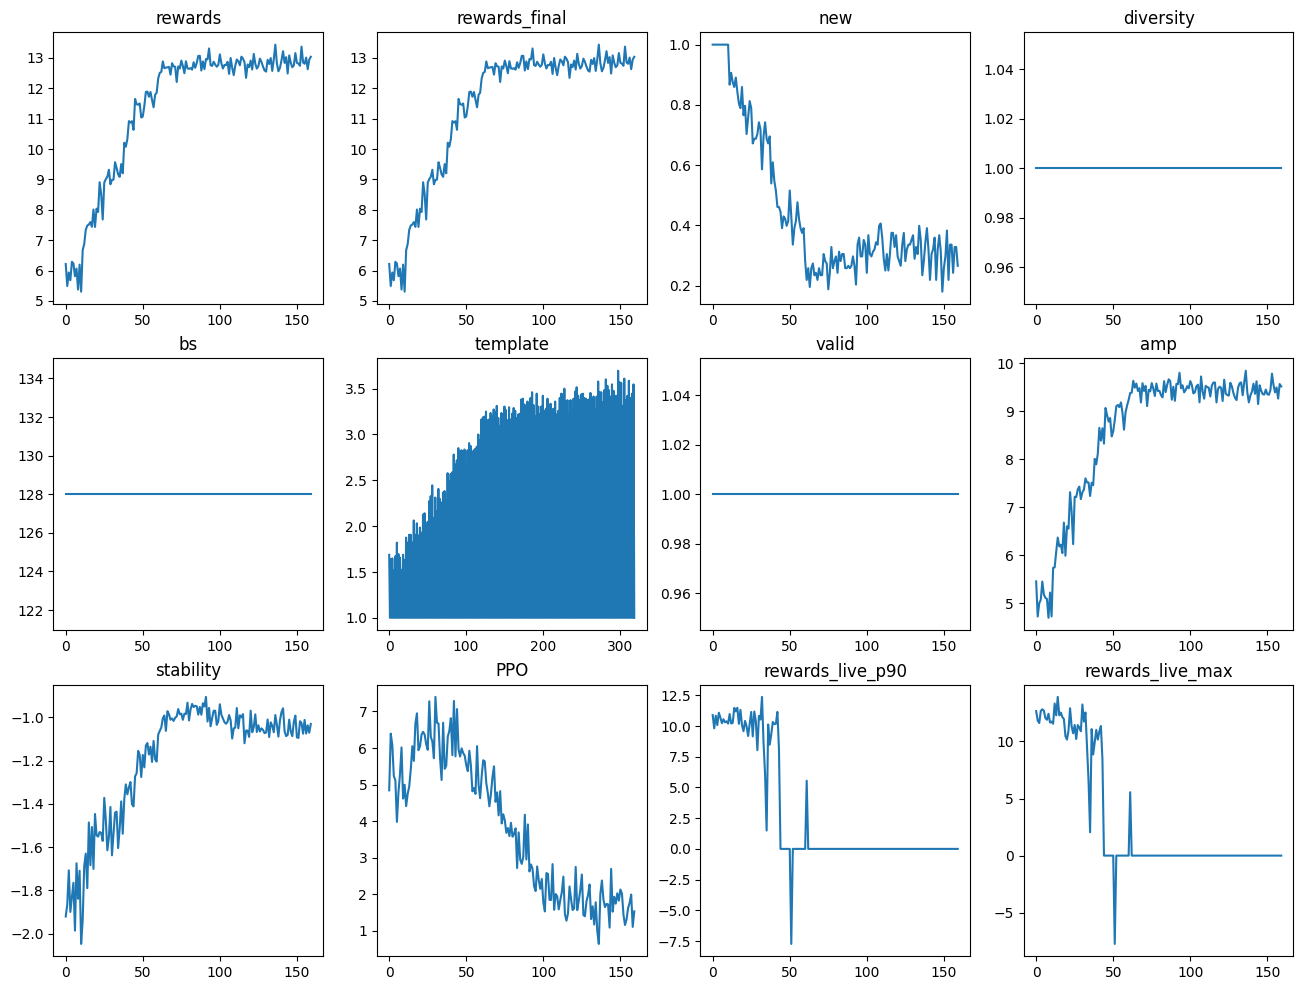

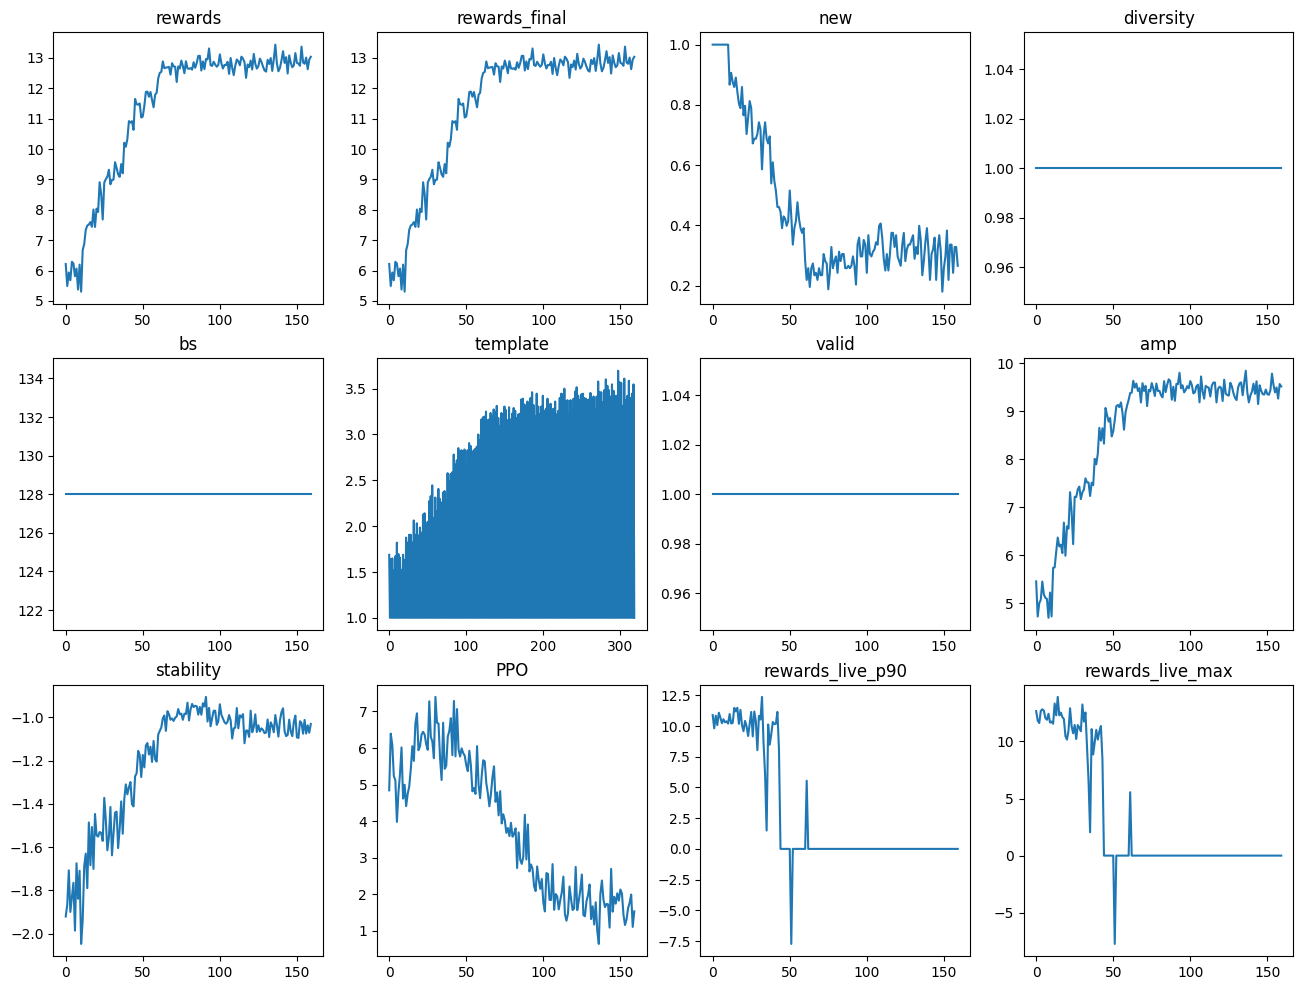

In [46]:
env.log.plot_metrics()

## Evaluation and selection

After generation, we retained only the sequences with the highest composite scores, reflecting both the predicted antimicrobial activity (from the CNN) and compliance with the physicochemical constraints (cationic charge, hydrophobicity, hydrophobic moment). The top‑scoring sequences were further filtered using ToxinPred 3.0, HemoPI2, and APEX to exclude potentially toxic or hemolytic peptides. From an initial pool of 140 sequences, we selected the 10 best candidates for synthesis and experimental validation.

In [52]:
env.log.df[env.log.df.rewards>12]

,samples,sources,rewards,rewards_final,template,amp,stability,PPO
13,GLGRFHSKGYGFGKVIVKTTA,base_buffer,13.396831,13.396831,1.0,10.000000,-1.603169,14.099522
985,KTILKVIIPGNKKAVKTA,base_buffer,13.212021,13.212021,1.0,10.000000,-1.787979,12.895812
1536,GLAGGLKKPFGNAALKLAKKAAHKL,live_buffer,13.321276,13.321276,1.0,10.000000,-0.678725,14.375699
1792,KKFAGKALATALGVAKKALSKSM,live_buffer,13.902944,13.902944,1.0,10.000000,-1.097057,15.236816
1884,RNWVWLKRPTYKFKPTPKNP,samples_tokswap_buffer,13.651706,13.651706,1.0,10.000000,-1.348295,15.959490
...,...,...,...,...,...,...,...,...
9055,VLGNWKSLYKAMKKMWQGKSFI,samples_tokswap_buffer,13.836872,13.836872,1.0,10.000000,-1.163128,0.025614
9059,GVPSGYFKAGNKPKHVTLKAASPT,samples_tokswap_buffer,13.157069,13.157069,1.0,10.000000,-0.842931,-0.093491
9073,GLNWKSLTKAMKKMWWGAQGIA,samples_tokswap_buffer,13.439679,13.439679,1.0,9.525104,-1.085424,-0.053914
9081,HIHVTKGAGSAGKTIVKTLIGRILGV,samples_tokswap_buffer,13.540248,13.540248,1.0,10.000000,-0.459752,1.271202


In [57]:
# ============================================================
# EXPORT GENERATED SEQUENCES
# ============================================================
# Save the top-scoring sequences (rewards > 12) to a CSV file
# in the 'results/' directory.
# ============================================================

import os

# Ensure the results directory exists
os.makedirs('results', exist_ok=True)

# Filter and save
tosave = env.log.df[env.log.df.rewards > 12]
tosave.to_csv('results/AMP_MRL>12.csv', index=False)
print(f"✅ Saved {len(tosave)} sequences to results/AMP_MRL>12.csv")

✅ Saved 1142 sequences to results/AMP_MRL>12.csv
